In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***2.Exploratory Data Analysis***

In [5]:
#Load the dataset
df = pd.read_csv('/content/bank_cleaned.csv')

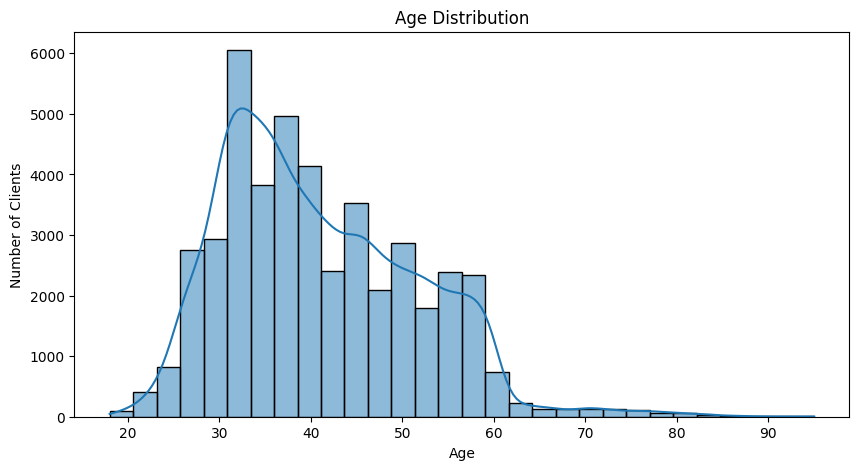

In [6]:
#Age Distribution

plt.figure(figsize=(10,5))
sns.histplot(df["age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.show()

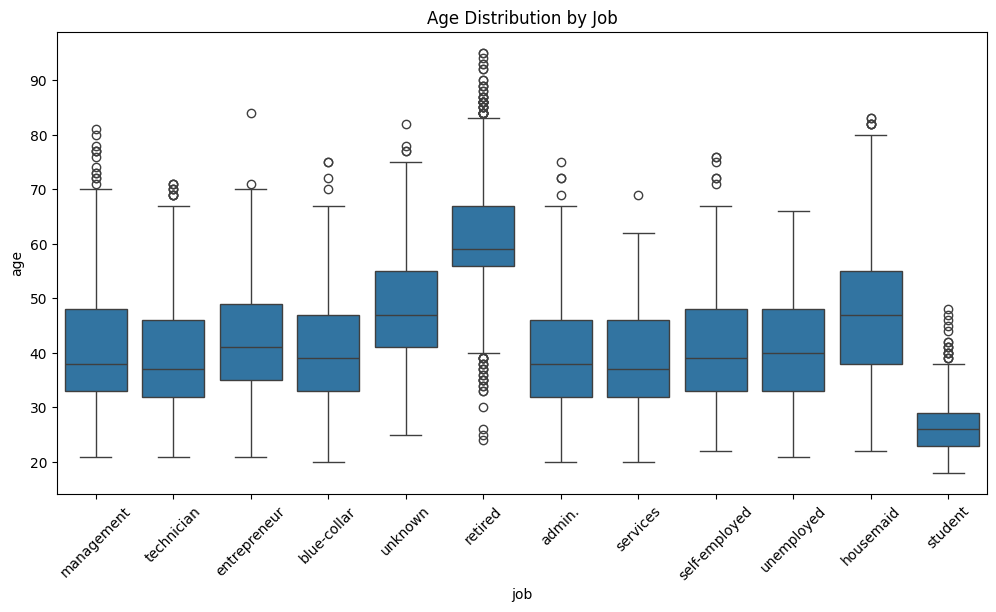

In [7]:
#Age by Job

plt.figure(figsize=(12,6))
sns.boxplot(x="job",y="age",data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution by Job")
plt.show()

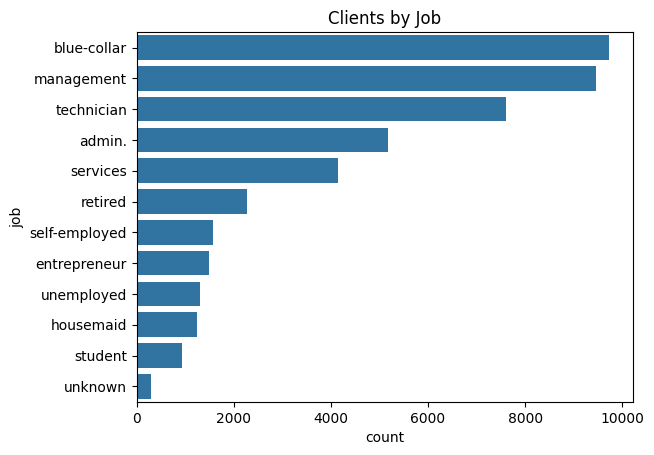

In [9]:
#Job Analysis
sns.countplot(y="job",data=df, order = df['job'].value_counts().index)
plt.title("Clients by Job")
plt.show()

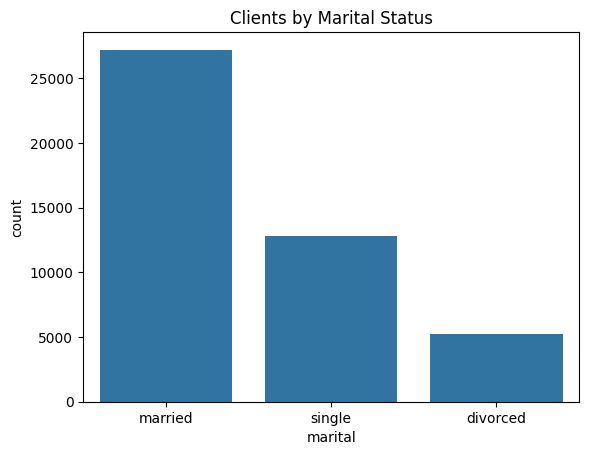

In [10]:
#Marital Status Analysis
df['marital'].value_counts()

sns.countplot(
    data=df,
    x='marital'
)

plt.title("Clients by Marital Status")
plt.show()

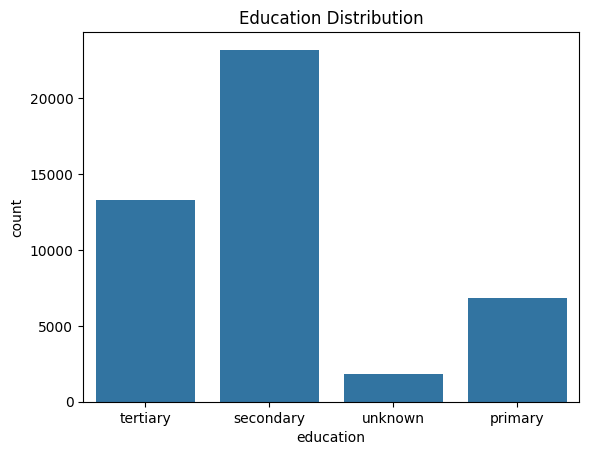

In [11]:
#Education Analysis
df['education'].value_counts()

sns.countplot(
    data=df,
    x='education'
)

plt.title("Education Distribution")
plt.show()

In [12]:
#Term Deposit Subscription by Education
pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
)*100

y,0,1
education,,
primary,91.373522,8.626478
secondary,89.440565,10.559435
tertiary,84.993610,15.006390
unknown,86.429725,13.570275


In [13]:
#Loan Analysis
loan_analysis = pd.crosstab(
    df['housing'],
    df['loan']
)

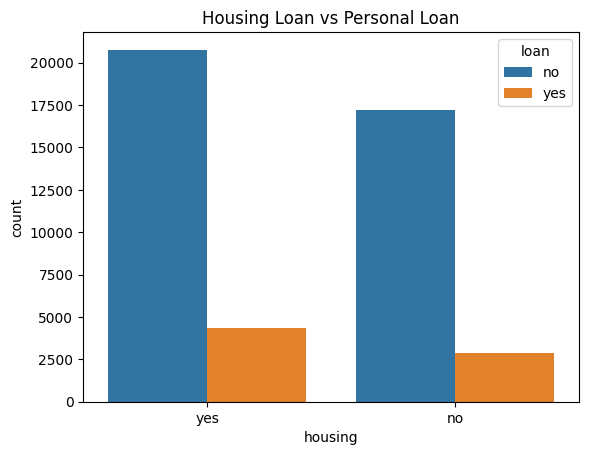

In [14]:
#Visualization
sns.countplot(
    data=df,
    x='housing',
    hue='loan'
)

plt.title("Housing Loan vs Personal Loan")
plt.show()

In [15]:
#Loan percentage
pd.crosstab(
    df['housing'],
    df['loan'],
    normalize='index'
)*100

loan,no,yes
housing,,
no,85.673024,14.326976
yes,82.622364,17.377636


In [16]:
#campaign Analysis
df['campaign'].describe()

,campaign
count,45211.000000
mean,2.763841
std,3.098021
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,63.000000


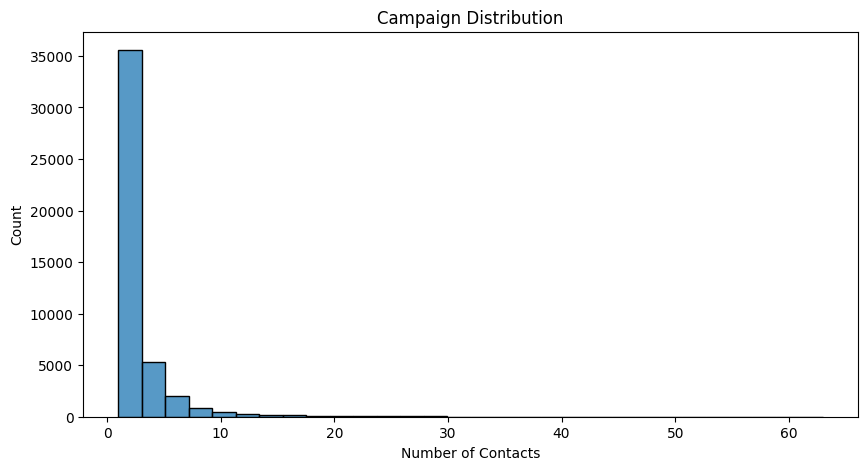

In [17]:
#Visualization:

plt.figure(figsize=(10,5))
sns.histplot(data=df,
             x="campaign",
             bins=30
             )
plt.title("Campaign Distribution")
plt.xlabel("Number of Contacts")
plt.show()

In [19]:
#Campaign Success Rate

campaign_success = (
    df.groupby('campaign')['y']
    .mean()
    .reset_index()
)



In [24]:
#Convert to Percentage:
campaign_success = campaign_success.rename(columns={'y':'success_rate'})
campaign_success['success_rate'] = campaign_success['success_rate']*100

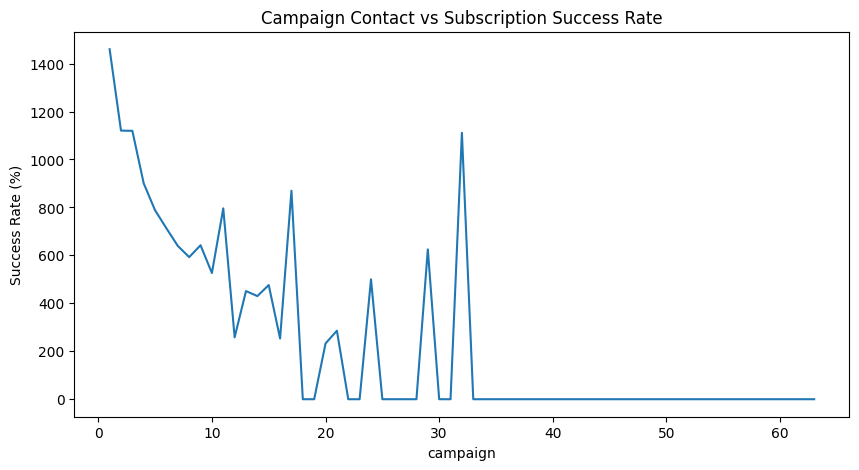

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=campaign_success,
    x='campaign',
    y='success_rate'
)

plt.title("Campaign Contact vs Subscription Success Rate")
plt.ylabel("Success Rate (%)")
plt.show()